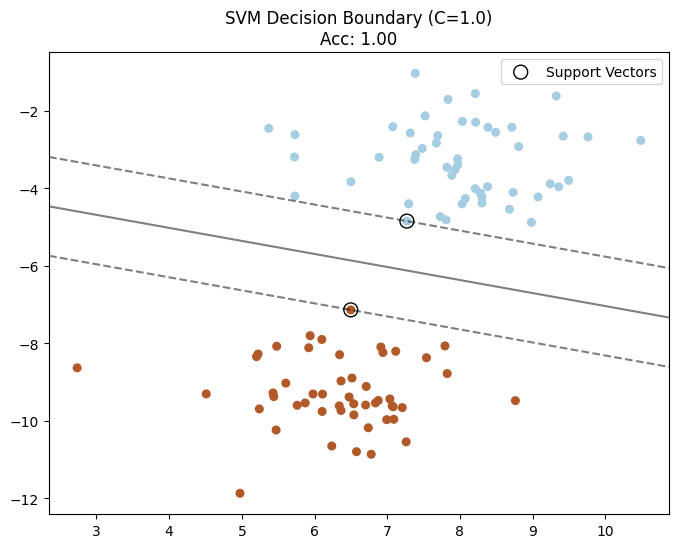

In [4]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

def svm_demo():
    # 1. Generate Data
    X, y = make_blobs(n_samples=100, centers=2, random_state=6)

    # 2. Train SVM (Linear Kernel)
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X, y)

    # 3. Visualization
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

    # Plot the decision function
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # Plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

    plt.title(f"SVM Decision Boundary (C=1.0)\nAcc: {clf.score(X, y):.2f}")
    plt.legend(loc="upper right")
    plt.show()


svm_demo()
